# Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from __future__ import print_function
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

2025-06-13 09:56:06.860111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749808567.043860      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749808567.095352      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def display(img, title=''):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Image Processing

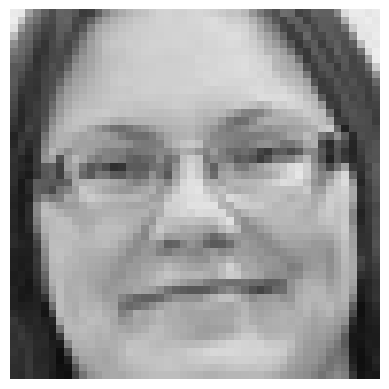

In [3]:
img = cv2.imread('/kaggle/input/fer2013/train//happy/Training_1206.jpg')
display(img)

In [4]:
img.shape

(48, 48, 3)

In [5]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [6]:
gaussian_blur = cv2.GaussianBlur(img, (3, 3), 0)

median_blur = cv2.medianBlur(img, 5)

average_blur = cv2.blur(img, (5, 5))

laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian_img = cv2.convertScaleAbs(laplacian)

canny = cv2.Canny(img, 50, 150)

# Unsharp mask
unsharp_mask = cv2.addWeighted(img, 1.5, gaussian_blur, -0,5, 0)

bilateral_filter = cv2.bilateralFilter(img, 9, 75, 75)

denoised_img = cv2.fastNlMeansDenoising(img, h=15, templateWindowSize=7, searchWindowSize=21)

equalized_hist = cv2.equalizeHist(img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(img)

denoised_hist = cv2.equalizeHist(denoised_img)
hist_denoised = cv2.fastNlMeansDenoising(equalized_hist, h=15, templateWindowSize=7, searchWindowSize=21)
denoised_clahe = clahe.apply(denoised_img)
hist_clahe_denoised = clahe.apply(equalized_hist)
hist_clahe_denoised = cv2.fastNlMeansDenoising(hist_clahe_denoised, h=15, templateWindowSize=7, searchWindowSize=21)

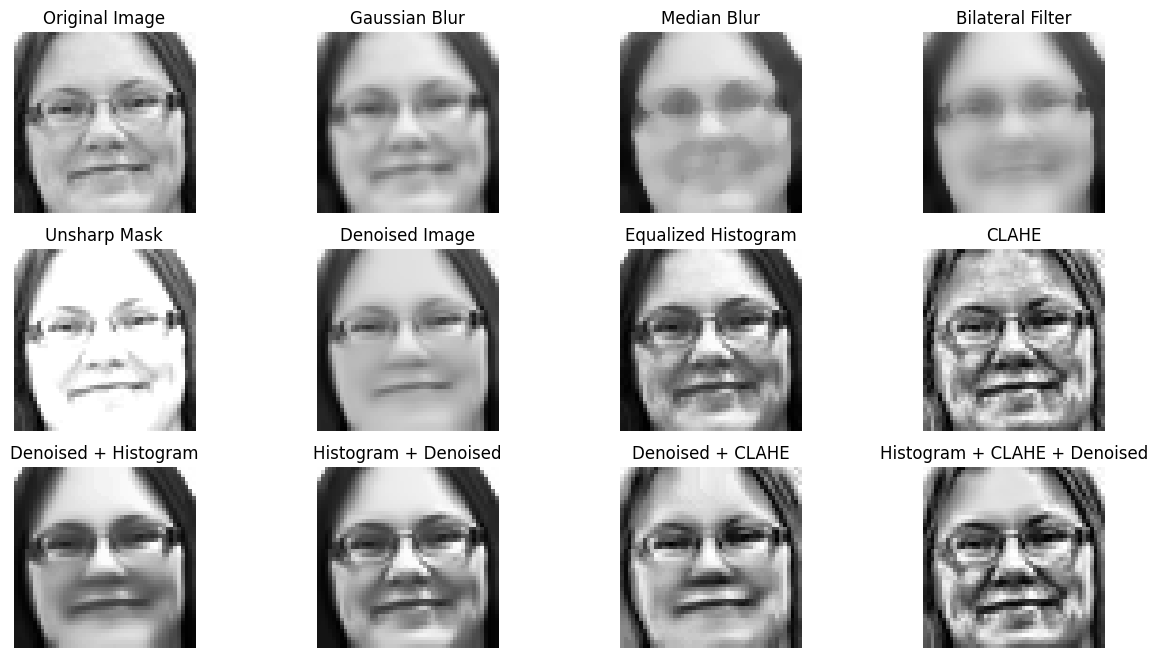

In [7]:
images = [
    img,
    gaussian_blur, 
    median_blur,
    bilateral_filter, 
    unsharp_mask,
    denoised_img, 
    equalized_hist, 
    clahe_img, 
    denoised_hist, 
    hist_denoised,
    denoised_clahe,
    hist_clahe_denoised
    ]
titles = [
    'Original Image',
    'Gaussian Blur', 
    'Median Blur',
    'Bilateral Filter', 
    'Unsharp Mask',
    'Denoised Image', 
    'Equalized Histogram', 
    'CLAHE', 
    'Denoised + Histogram', 
    'Histogram + Denoised',
    'Denoised + CLAHE',
    'Histogram + CLAHE + Denoised'
    ]

plt.figure(figsize=(15, 8))
for i in range(len(images)):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

In [8]:
IMG_SIZE = 48

In [9]:
def preprocess_image(image_path):
    # load the image
    if not os.path.exists(image_path):
        return None
    if not os.path.isfile(image_path):
        return None
    if not image_path.lower().endswith(('.png', '.jpg', '.jpeg')):
        return None
    
    img = cv2.imread(image_path)
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hist_eq = cv2.equalizeHist(img_gray)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(hist_eq)

    denoised_face = cv2.fastNlMeansDenoising(clahe_img, h=15, templateWindowSize=7, searchWindowSize=21)

    resized_img = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))

    norm_img = resized_img.astype('float32') / 255.0

    return norm_img

# Prepare Data

In [10]:
train_data_path = '/kaggle/input/fer2013/train/'
test_data_path = '/kaggle/input/fer2013/test/'

In [11]:
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'neutral', 'surprise']

label_map = {emotion: idx for idx, emotion in enumerate(emotion_labels)}
label_map

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'sad': 4,
 'neutral': 5,
 'surprise': 6}

In [12]:
def load_images(data_dir):
    image_paths = []
    labels = []

    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        if os.path.isdir(label_path) and label in emotion_labels: 
            for file in os.listdir(label_path):
                if file.lower().endswith('.jpg'):
                    image_path = os.path.join(label_path, file)
                    image_paths.append(image_path)
                    labels.append(label)
                    
    # Shuffle the data and labels together
    image_paths, labels = shuffle(image_paths, labels, random_state=40)
    return image_paths, labels

In [13]:
# Load and shuffle train and validation
X_train_raw, y_train_raw = load_images(train_data_path)

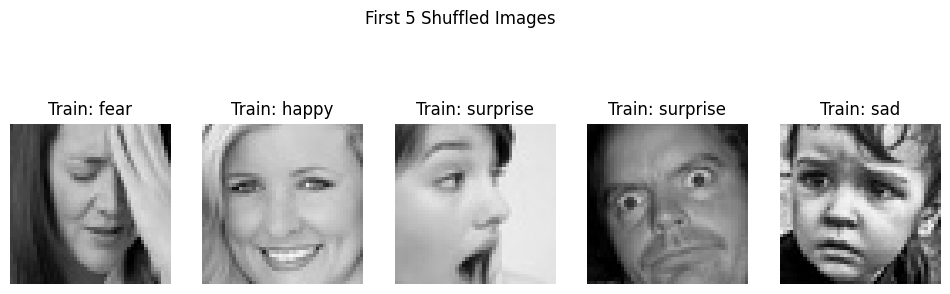

In [14]:
# Show first 5 from train
plt.figure(figsize=(12, 4))
for i in range(5):
    img = cv2.imread(X_train_raw[i], cv2.IMREAD_GRAYSCALE)  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((48, 48))  
    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Train: {y_train_raw[i]}")
    plt.axis('off')
plt.suptitle("First 5 Shuffled Images")
plt.show()

In [15]:
def process_file(emotion, file_path):
    processed_image = preprocess_image(file_path)
    if processed_image is not None:
        return processed_image, label_map[emotion]
    return None

### Prepare Train Data

In [16]:
X_train = []
y_train = []

In [17]:
for emotion in emotion_labels:
    folder_path = os.path.join(train_data_path, emotion)
    files = os.listdir(folder_path)

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(process_file, emotion, os.path.join(folder_path, f)): f for f in files}

        for future in tqdm(as_completed(futures), total=len(futures), desc=f"Processing {emotion}", unit="img"):
            result = future.result()
            if result is not None:
                processed_image, label = result
                X_train.append(processed_image)
                y_train.append(label)

Processing surprise: 100%|██████████| 3171/3171 [00:09<00:00, 349.74img/s]


In [18]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_cat_train = to_categorical(y_train, num_classes=len(emotion_labels))

print(f'Loaded {len(X_train)} images successfully.')

Loaded 28709 images successfully.


### Prepare Test Data

In [19]:
X_test = []
y_test = []

In [20]:
for emotion in emotion_labels:
    folder_path = os.path.join(test_data_path, emotion)
    files = os.listdir(folder_path)

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(process_file, emotion, os.path.join(folder_path, f)): f for f in files}

        for future in tqdm(as_completed(futures), total=len(futures), desc=f"Processing {emotion}", unit="img"):
            result = future.result()
            if result is not None:
                processed_image, label = result
                X_test.append(processed_image)
                y_test.append(label)

Processing surprise: 100%|██████████| 831/831 [00:02<00:00, 381.73img/s]


In [21]:
X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_cat_test = to_categorical(y_test, num_classes=len(emotion_labels))

print(f'Loaded {len(X_test)} images successfully.')

Loaded 7178 images successfully.


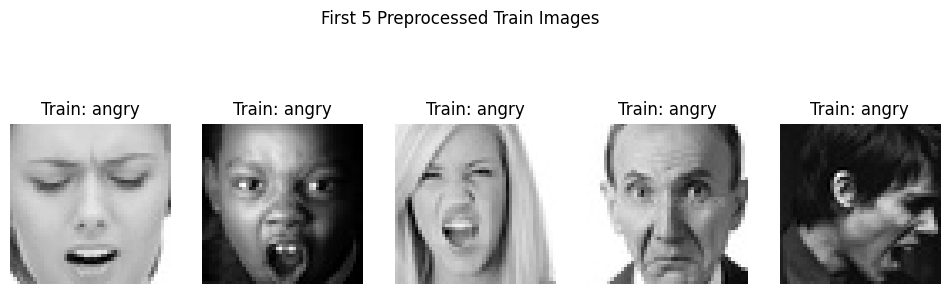

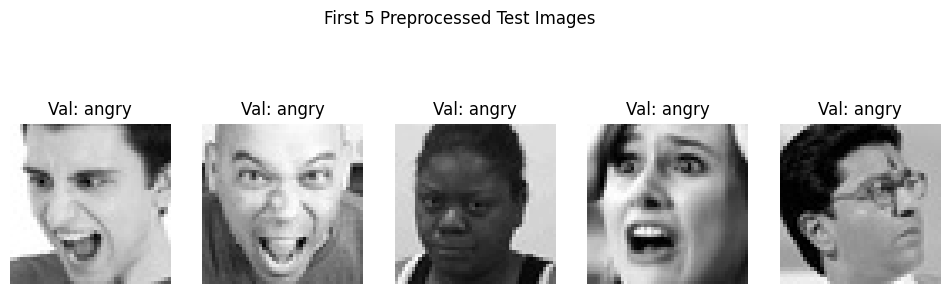

In [22]:
# Show first 5 preprocessed train images
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"Train: {emotion_labels[y_train[i]]}")
    plt.axis('off')
plt.suptitle("First 5 Preprocessed Train Images")
plt.show()

# Show first 5 preprocessed validation images
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"Val: {emotion_labels[y_test[i]]}")
    plt.axis('off')
plt.suptitle("First 5 Preprocessed Test Images")
plt.show()

## Check Class Imbalance

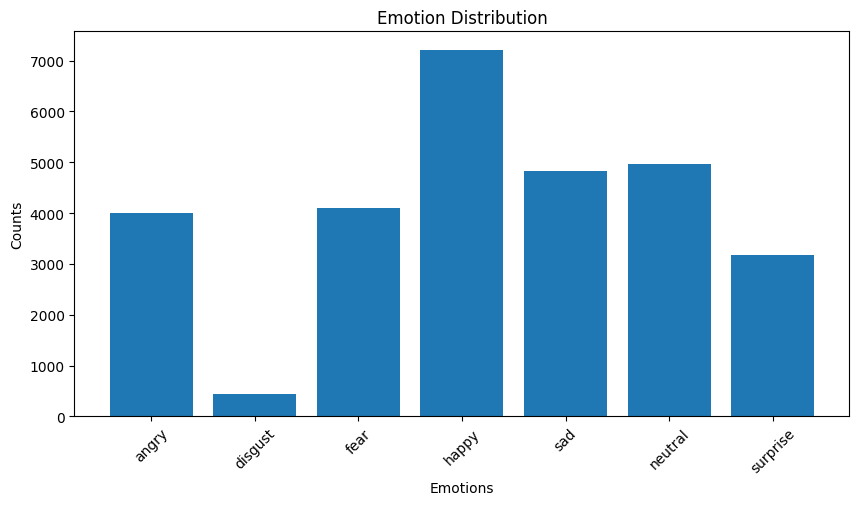

In [23]:
value_counts = np.bincount(y_train)
plt.figure(figsize=(10, 5))
plt.bar(emotion_labels, value_counts)
plt.xlabel("Emotions")
plt.ylabel("Counts")
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

We see here that there's class imbalance, we will have to assign weights to each class

In [24]:
# shuffle the data
shuffle_train_indices = np.random.permutation(len(X_train)-1)

X_train = X_train[shuffle_train_indices]
y_train = y_train[shuffle_train_indices]

shuffle_test_indices = np.random.permutation(len(X_test)-1)

X_test = X_test[shuffle_test_indices]
y_test = y_test[shuffle_test_indices]

print("Shuffled Data Successfully")

Shuffled Data Successfully


# Feature Extraction

In [25]:
from skimage.feature import hog, local_binary_pattern
from skimage.filters import prewitt, scharr, laplace, gabor
from skimage.restoration import denoise_tv_chambolle
import cv2
import numpy as np

def extract_features_from_image(img):
    # Ensure the image is in 2D grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # Normalize image for OpenCV if needed
    if gray.max() <= 1:
        gray = (gray * 255).astype(np.uint8)

    # 1. Sobel Edge Detection
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_edge = np.sqrt(sobelx**2 + sobely**2)

    # 2. Canny Edge Detection
    try:
        canny_edges = cv2.Canny(gray, 100, 200)
    except Exception as e:
        print(f"Error applying Canny edge detection: {e}")
        canny_edges = np.zeros_like(gray)

    # 3. HOG
    fd, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

    # 4. Local Binary Pattern (LBP)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')

    # 5. Gaussian Blur
    blurred_img = cv2.GaussianBlur(gray, (5, 5), 0)

    # 6. Laplacian
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)

    # 7. Scharr
    scharr_edge = scharr(gray)

    # 8. Prewitt
    prewitt_edge = prewitt(gray)

    # 9. Median Filter
    median_filtered = cv2.medianBlur(gray, 5)

    # 10. Gabor Filter
    gabor_response, _ = gabor(gray, frequency=0.6)

    # Return all 2D feature images
    return (
        sobel_edge,
        canny_edges,
        hog_image,
        lbp,
        blurred_img,
        laplacian,
        scharr_edge,
        prewitt_edge,
        median_filtered,
        gabor_response
    )

# Dataset feature extraction (same as before)
def extract_features_for_dataset(X_data):
    all_features = []
    for img in X_data:
        img = img.reshape(48, 48)
        features = extract_features_from_image(img)
        all_features.append(features)
    return np.array(all_features)

### Apply Parallel Processing in Feature Extraction

In [26]:
from joblib import Parallel, delayed

def extract_features_parallel(X_data, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(extract_features_from_image)(img.reshape(IMG_SIZE, IMG_SIZE)) for img in X_data
    )
    return np.array(results)

In [27]:
# Assuming X_train and X_test are your training and test datasets
X_train_feat = extract_features_parallel(X_train)
X_test_feat = extract_features_parallel(X_test)

# Print shapes of the extracted feature sets
print(f"Shape of extracted features for X_train: {X_train_feat.shape}")
print(f"Shape of extracted features for X_test: {X_test_feat.shape}")

Shape of extracted features for X_train: (28708, 10, 48, 48)
Shape of extracted features for X_test: (7177, 10, 48, 48)


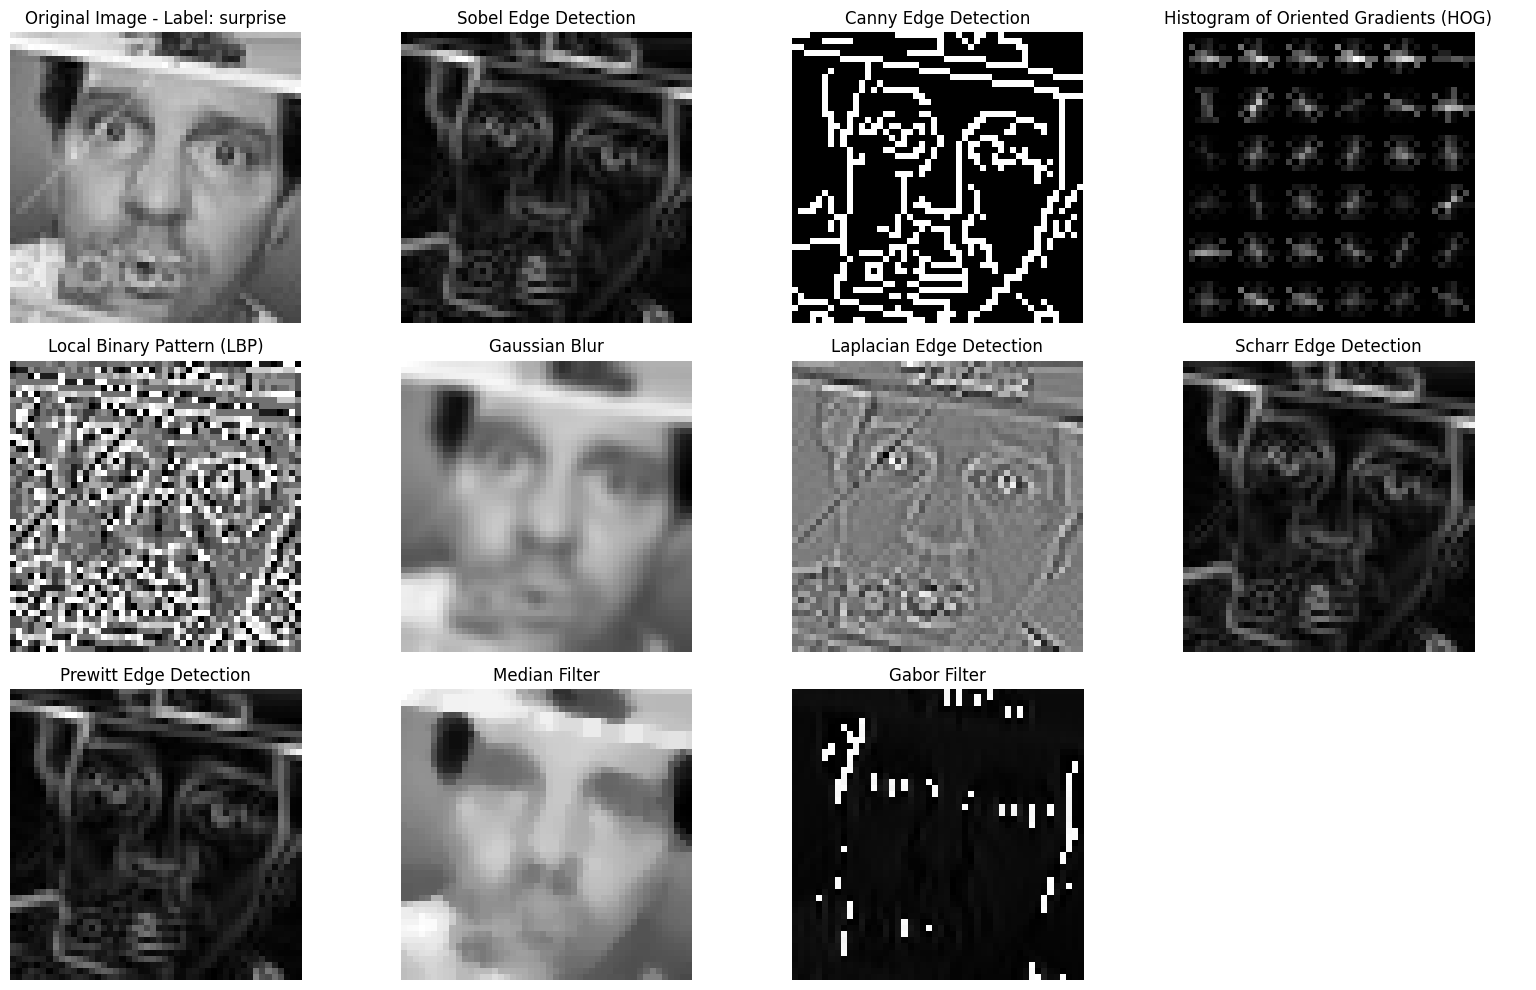

In [28]:
# First image and label
first_image = X_train[0].reshape(48, 48)
first_image_label = emotion_labels[y_train[0]]

# Extract features (this function now returns 10 feature images)
features = extract_features_from_image(first_image)

# Titles for each feature
titles = [
    f"Original Image - Label: {first_image_label}",
    "Sobel Edge Detection",
    "Canny Edge Detection",
    "Histogram of Oriented Gradients (HOG)",
    "Local Binary Pattern (LBP)",
    "Gaussian Blur",
    "Laplacian Edge Detection",
    "Scharr Edge Detection",
    "Prewitt Edge Detection",
    "Median Filter",
    "Gabor Filter"
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Flatten axes to loop easily
axes = axes.flatten()

# Plot original image first
axes[0].imshow(first_image, cmap='gray')
axes[0].set_title(titles[0])
axes[0].axis('off')

# Plot all feature maps
for i, feature_img in enumerate(features):
    axes[i + 1].imshow(feature_img, cmap='gray')
    axes[i + 1].set_title(titles[i + 1])
    axes[i + 1].axis('off')

# Hide any remaining unused subplots (if less than 12)
for j in range(len(features) + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Flatten the extracted feature set
X_train_feat_flattened = X_train_feat.reshape(X_train_feat.shape[0], -1)  # Flatten each sample
X_test_feat_flattened = X_test_feat.reshape(X_test_feat.shape[0], -1)  # Flatten each sample

# Print the new shape to verify
print(f"Shape of flattened features for X_train: {X_train_feat_flattened.shape}")
print(f"Shape of flattened features for X_test: {X_test_feat_flattened.shape}")

Shape of flattened features for X_train: (28708, 23040)
Shape of flattened features for X_test: (7177, 23040)


# Model Construction & Evaluation

## Random Forest

In [30]:
# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, verbose=1)

# Train the model
rf_model.fit(X_train_feat_flattened, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.5min
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  5.1min finished


RandomForestClassifier(random_state=42, verbose=1)

In [31]:
# Predict on the test data
y_pred = rf_model.predict(X_test_feat_flattened)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test data: {accuracy * 100:.2f}%")

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s


Accuracy on test data: 46.54%
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.20      0.28       958
           1       1.00      0.28      0.44       111
           2       0.46      0.26      0.33      1024
           3       0.46      0.82      0.59      1774
           4       0.36      0.34      0.35      1247
           5       0.43      0.41      0.42      1233
           6       0.74      0.56      0.64       830

    accuracy                           0.47      7177
   macro avg       0.56      0.41      0.44      7177
weighted avg       0.48      0.47      0.44      7177

Accuracy: 0.4654


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished


## XGBoost

In [32]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Convert data into DMatrix, which is the format XGBoost prefers
dtrain = xgb.DMatrix(X_train_feat_flattened, label=y_train)
dval = xgb.DMatrix(X_test_feat_flattened, label=y_test)

# Set hyperparameters for XGBoost
params = {
    'objective': 'multi:softmax',
    'num_class': len(set(y_train)),
    'max_depth': 6,
    'eta': 0.1,
    'eval_metric': 'merror',
    'tree_method': 'hist',
    'device': 'cuda'
}


# Train the model
num_round = 100  # number of boosting rounds (trees)
bst = xgb.train(params, dtrain, num_round)

# Make predictions on the validation data
y_pred_xgb = bst.predict(dval)

# Evaluate the accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy on test data using XGBoost: {accuracy_xgb * 100:.2f}%")

Accuracy on test data using XGBoost: 51.57%


### Data Augmentation

In [33]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [34]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))
class_weights

{0: 1.0265689254425174,
 1: 9.406290956749672,
 2: 1.0010111928588863,
 3: 0.5684189684189684,
 4: 0.8490979000295771,
 5: 0.826010645950223,
 6: 1.2937359170797658}

## CNN

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, SpatialDropout2D, Activation
)
from tensorflow.keras.regularizers import l2


model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same',),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same',),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same',),
    BatchNormalization(),
    Dropout(0.3),

    Conv2D(512, (3,3), activation='relu', padding='same',),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dropout(0.4),

    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1749809332.319282      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12299 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [36]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 6, 6, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 6, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,104,455 (8.03 MB)

 Trainable params: 2,102,471 (8.02 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [37]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)


In [38]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [39]:
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_train.shape

(22966, 48, 48, 1)

In [40]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val), 
    epochs=50,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1749809340.182599     202 service.cc:148] XLA service 0x30c2d6f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749809340.183243     202 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1749809340.769134     202 cuda_dnn.cc:529] Loaded cuDNN version 90300


  7/359 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1321 - loss: 2.3292

I0000 00:00:1749809346.876069     202 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


359/359 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.1685 - loss: 2.0795 - val_accuracy: 0.1677 - val_loss: 1.9321 - learning_rate: 0.0010
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.2505 - loss: 1.8241 - val_accuracy: 0.3370 - val_loss: 1.7305 - learning_rate: 0.0010
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3153 - loss: 1.7066 - val_accuracy: 0.3777 - val_loss: 1.7000 - learning_rate: 0.0010
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3530 - loss: 1.6358 - val_accuracy: 0.2884 - val_loss: 1.9657 - learning_rate: 0.0010
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.3781 - loss: 1.6258 - val_accuracy: 0.4147 - val_loss: 1.5420 - learning_rate: 0.0010
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3942 - loss: 1.5830 - val_accuracy: 0.3520 - val_loss: 1.7109 - learning_rate: 0.0010
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4131 - loss: 1.5296 - val

In [41]:
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test.shape

(7177, 48, 48, 1)

In [42]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5242 - loss: 1.2355
Test Accuracy: 53.06%


In [43]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.45      0.42       958
           1       0.21      0.66      0.32       111
           2       0.50      0.08      0.14      1024
           3       0.73      0.81      0.77      1774
           4       0.50      0.28      0.36      1247
           5       0.43      0.65      0.52      1233
           6       0.60      0.77      0.68       830

    accuracy                           0.53      7177
   macro avg       0.48      0.53      0.46      7177
weighted avg       0.54      0.53      0.50      7177



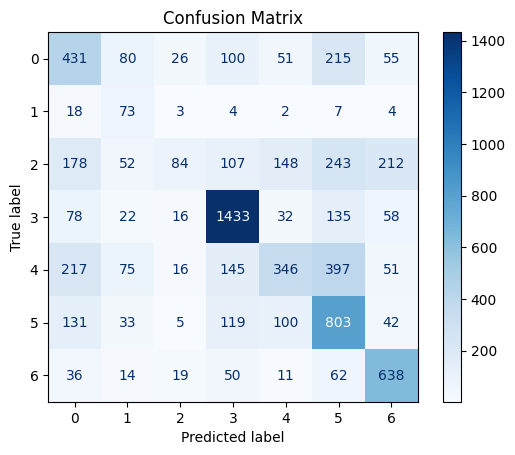

In [45]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

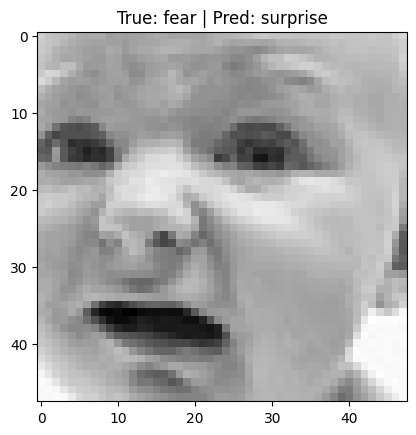

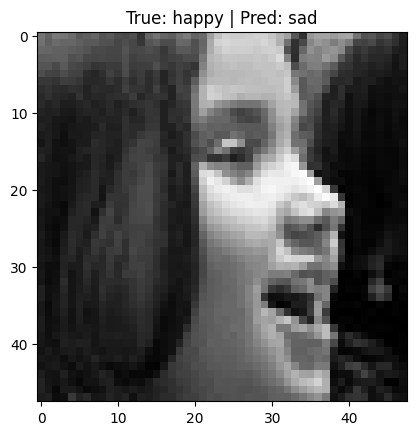

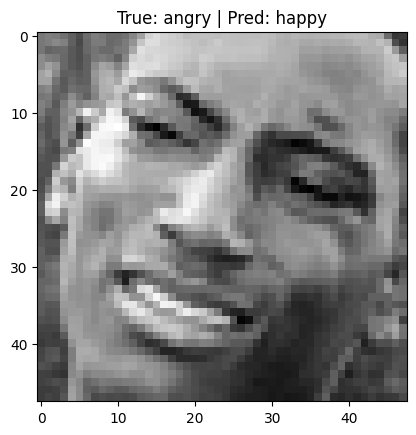

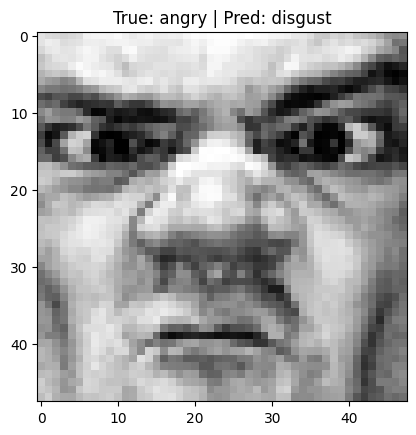

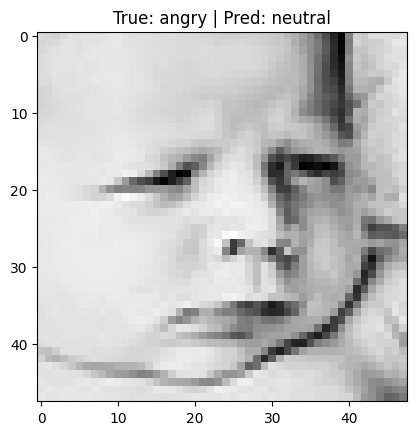

In [46]:
# Visualize some missclassified samples
wrong = np.where(y_pred != y_test)[0]


for i in wrong[:5]:
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"True: {emotion_labels[y_test[i]]} | Pred: {emotion_labels[y_pred[i]]}")
    plt.show()

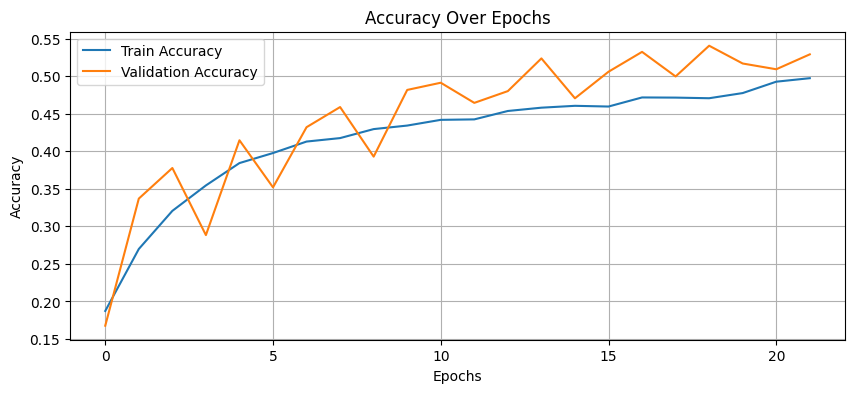

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

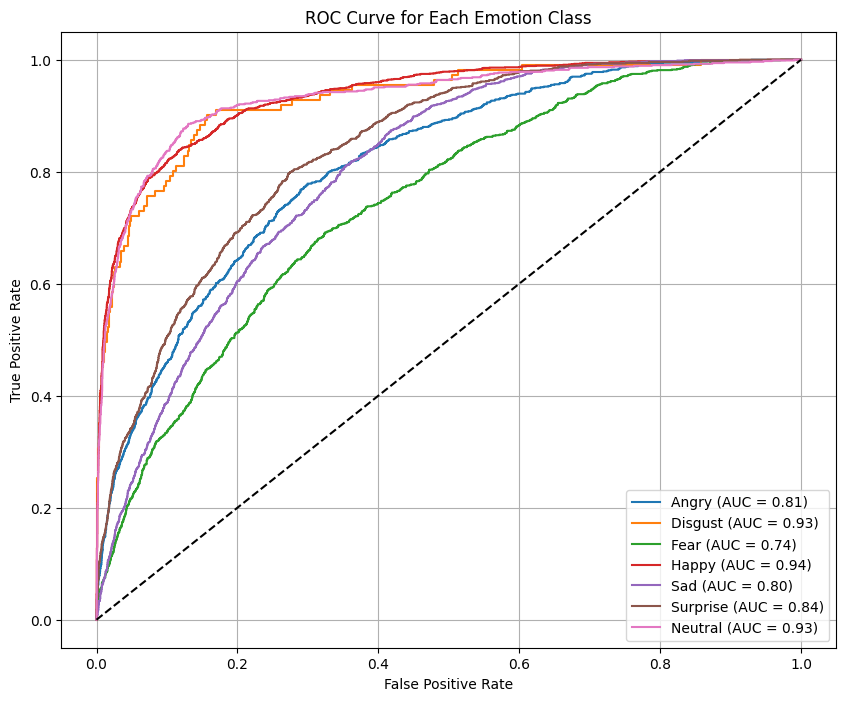

In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Your integer class labels (0 to 6), shape: (num_samples,)
# Example:
# y_true = np.array([0, 2, 1, 4, ...])
# y_pred_probs = model.predict(X_test)  # shape: (num_samples, 7)

# 1. Binarize the y_true just for ROC plotting
y_true_bin = label_binarize(y_test, classes=list(range(7)))  # shape: (num_samples, 7)

# 2. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot ROC curves
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

plt.figure(figsize=(10, 8))
for i in range(7):
    plt.plot(fpr[i], tpr[i], label=f'{emotion_labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Emotion Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## ResNet pre-trained

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight

In [50]:
data_dir = '/kaggle/input/fer2013'
num_classes = 7
epochs = 30
early_stop_patience = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Data Transforms ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- Dataset Loaders ---
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

print("data augmentation done.")

Using device: cuda
data augmentation done.


In [51]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# --- Compute class weights ---
labels = [sample[1] for sample in train_dataset]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("data preprocessing done.")

data preprocessing done.


In [52]:
# --- Model Setup ---
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Fine-tune only the last block and fc
for name, param in model.named_parameters():
    print(name)
    param.requires_grad = False
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# --- Loss & Optimizer ---
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

In [53]:
# --- Training Loop with Early Stopping ---
best_val_acc = 0
patience = 0

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}: Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience = 0
        torch.save(model.state_dict(), 'best_resnet_model.pt')
    else:
        patience += 1
        if patience >= early_stop_patience:
            print("Early stopping triggered.")
            break


Epoch 1: Train Acc: 0.2784 | Val Acc: 0.4677
Epoch 2: Train Acc: 0.3503 | Val Acc: 0.5309
Epoch 3: Train Acc: 0.3765 | Val Acc: 0.5542
Epoch 4: Train Acc: 0.4021 | Val Acc: 0.5391
Epoch 5: Train Acc: 0.4090 | Val Acc: 0.5644
Epoch 6: Train Acc: 0.4361 | Val Acc: 0.5836
Epoch 7: Train Acc: 0.4376 | Val Acc: 0.5864
Epoch 8: Train Acc: 0.4510 | Val Acc: 0.5568
Epoch 9: Train Acc: 0.4574 | Val Acc: 0.5777
Epoch 10: Train Acc: 0.4681 | Val Acc: 0.5922
Epoch 11: Train Acc: 0.4852 | Val Acc: 0.6117
Epoch 12: Train Acc: 0.4963 | Val Acc: 0.6088
Epoch 13: Train Acc: 0.4948 | Val Acc: 0.6126
Epoch 14: Train Acc: 0.4983 | Val Acc: 0.6158
Epoch 15: Train Acc: 0.5043 | Val Acc: 0.6096
Epoch 16: Train Acc: 0.5082 | Val Acc: 0.6199
Epoch 17: Train Acc: 0.5112 | Val Acc: 0.6218
Epoch 18: Train Acc: 0.5042 | Val Acc: 0.6222
Epoch 19: Train Acc: 0.5120 | Val Acc: 0.6158
Epoch 20: Train Acc: 0.5144 | Val Acc: 0.6186
Epoch 21: Train Acc: 0.5128 | Val Acc: 0.6209
Epoch 22: Train Acc: 0.5164 | Val Acc: 0.62